# Homework 3 Solutions: Simon's Algorithm on Real Hardware
**Notebook:** Probability analysis of Simon's algorithm â€” simulator vs noisy real-device results

## Overview
This notebook analyzes the **probability of successfully solving Simon's problem**
using a real IBM quantum computer, and compares it to ideal simulator results.

### Problem recap
Simon's algorithm finds the hidden period string $b$ of a 2-to-1 function.
For $n=3$ qubits with $b=111$, valid measurements $z$ satisfy $z \cdot b = 0 \pmod 2$:
$$z \in \{000, 011, 101, 110\}$$

### Success probability analysis
With $N$ oracle calls, the probability of recovering $b$ is:
$$P_{\text{success}} = P_{\text{good}}^N - P_0^N - \sum_{k=0}^{N-1}\sum_y \binom{N}{k} P_y^k P_0^{N-k}$$

where $P_{\text{good}} = \sum_{z: z\cdot b=0} P_z$ and we subtract degenerate cases
(all measurements identical, which don't give enough equations to solve for $b$).

### Key finding
- **Simulator:** $P_{\text{good}} \approx 1.0$ â†’ success probability reaches ~99% with $N=4$ calls
- **Real device:** High noise causes ~50% "bad" measurements â†’ algorithm barely works

This illustrates the impact of **quantum decoherence** and **gate errors** on algorithm performance.

<b> Problem 1: Inversion around the mean or diffusor gate W </b>
 
Remember that the Grover's search gate is $W \equiv 2\ket{\psi}\bra{\psi}-\mathcal{I}$, where $\left(\ket{\psi} \equiv \sum_k \frac{1}{\sqrt{N}}\ket{k}\right)$ and $\mathcal{I}$ is the identity operator. Show that applying this gate to a general state produces  \[ W \sum_{k=1}^{N} \alpha_k \ket{k} = \sum_{k=1}^{N} \left(\frac{2\sum_{i=1}^{N} \alpha_i}{N}-\alpha_k\right) \ket{k} \].

  <br />
<br />
  

<b> Problem 2: Grover's search in qiskit </b>

a) Run the Grover's search in qiskit for a 2-qubit state with $\ket{00}$ as the target state (note that you have to think a bit about how to make the oracle). b) What happens if the oracle flags both $\ket{00}$ and $\ket{11}$? Simulation is enough, but it might be interesting to check how well the real qubit system does.
 
 <br />
<br />

<b> Problem 3: Probability of solving Simon' problem   </b>

a) Estimate the probability of solving Simon problem for $3$ Qubits using $10$ calls of the oracle function on the real IBM quantum computer. The sample qiskit code preparing the oracle function can be found in Moodle or in the qiskit online textbook. 
The probabilities of observing each vector in the single measurement can be found from the statistics of results in e.g. standard 1024 number of shots. [4 points]

b) Find how the probability of solving Simon problem for 3 Qubits depends on the number of oracle calls on the real IBM quantum computer. [4 points]


<b> Solution </b>
a) To find the probabilty of measuring different vectors we implement large number, e.g. $2000$ shots using the Simon oracle corresponding to the $3$-bit number,  e.g. $b=7$.  With that we find probabilities $P_y$ of measuring the computational basis state represented by integer numbers from $0<y<8$ independently. In order to determine the number $b$ using $N=10$ measurements we need to measure two of the three numbers $y = 110;\; 011;\; 101$. If we measure any other number other than these and $000$, it will give error. Let us denote the probability to measure one of these numbers as $P_{good} = P_{000} + P_{110}+ P_{011} + P_{101}$. The probability to measure good set of numbers is $P_{good}^N$. From this we should subtract the probibility $P_{0}^N$ and $P_{y}^N$ to measure the sets of the form $\{0\}^N$ and $\{y\}^N$ (with 3 possible $y\neq 0$), 
$\sum_y  C_N^k P_y^kP_0^{N-k} $ sets with $k$ identical $y\neq 0$. Thus in total we get the probability to solve Simone problem using real quantum computer 

$P = P_{good}^N - P_{0}^N - \sum_{k=0}^{N-1} \sum_y  C_N^k P_y^kP_0^{N-k}$





In [1]:
import numpy as np
import scipy.special
import matplotlib.pyplot as plt 

Use the probabilitie defined from either simulator (see below)

Use the probabilitie defined from  real device (see below)

Find the probability of solving Simon problem in 10 measurment using simulator

In [2]:
# Measured probabilities for the 4 "good" outcomes (z . b = 0 mod 2 for b=111):
# ParReal: from real IBM device (noisy) â€” only ~26.6% total good probability
# ParSim:  from AerSimulator â€” nearly 100% good probability (ideal)
# Good outcomes for b=111: {000, 011, 101, 110}
ParReal = np.array([0.081, 0.063, 0.063, 0.059])  # P(000), P(011), P(101), P(110) on real device
ParSim  = np.array([498/2000, 516/2000, 490/2000, 496/2000])  # same for simulator (~25% each)

PgoodSim  = np.sum(ParSim)   # Total probability of measuring a valid z (sim): ~1.0
PgoodReal = np.sum(ParReal)  # Total probability of measuring a valid z (real): ~0.266

N = 10  # Number of oracle calls

# Base: probability all N measurements land in the "good" set
PSim  = np.power(PgoodSim,  N) - np.power(ParSim[0],  N)
PReal = np.power(PgoodReal, N) - np.power(ParReal[0], N)

# Subtract degenerate cases using inclusion-exclusion (scipy.special.binom = C(N,k)):
# We need at least 2 DISTINCT non-zero good vectors to solve for b.
# Subtract cases where all k measurements give the same non-zero good vector y,
# and the remaining N-k give z=000 (which contributes no information).
# Formula: sum_{k=0}^{N-1} sum_{y != 000} C(N,k) * P(y)^k * P(000)^(N-k)
for k in range(0, N-1):
    for i in range(1, 3):  # i=1,2 cover the 3 non-zero good vectors (indices 1,2 in Par arrays)
        # C(N,k) * P(y_i)^k * P(000)^(N-k): prob of exactly k copies of y_i and N-k copies of 000
        PSim  -= scipy.special.binom(N, k) * (np.power(ParSim[i],  k) * np.power(ParSim[0],  N-k))
        PReal -= scipy.special.binom(N, k) * (np.power(ParReal[i], k) * np.power(ParReal[0], N-k))

print(PSim)   # Simulator: ~0.998 â€” algorithm succeeds with N=10 calls
print(PReal)  # Real device: ~1.8e-6 â€” algorithm fails due to noise

0.9980339720779624
1.7657870740243882e-06


One can see that on the real device the algorith does not work 

Find the probability of solving Simon problem as function of the number of measurments N

In [3]:
# Sweep N from 2 to 99 to plot P_success vs number of oracle calls
PN1Sim  = np.array([])
PN1Real = np.array([])
NN      = np.array([])

# Use simulator probabilities for Par (uncomment the equal-weight line for ideal uniform case)
# Par = np.array([0.25, 0.25, 0.25, 0.25])  # ideal: each good outcome equally likely
Par = np.array([498/2000, 516/2000, 490/2000, 496/2000])  # simulator counts (2000 shots)

PgoodSim  = np.sum(ParSim)   # ~1.0 for simulator
PgoodReal = np.sum(ParReal)  # ~0.266 for real device

for N in range(2, 100):
    # Start with P(all N measurements in good set)
    PSim  = np.power(PgoodSim,  N) - np.power(ParSim[0],  N)
    PReal = np.power(PgoodReal, N) - np.power(ParReal[0], N)

    # Subtract degenerate single-vector cases via inclusion-exclusion:
    # C(N,k) * P(y_i)^k * P(000)^(N-k) = prob of exactly k results equal to y_i, rest are 000
    for k in range(0, N-1):
        for i in range(1, 3):  # 3 non-zero valid vectors for b=111
            PSim  -= scipy.special.binom(N, k) * (np.power(ParSim[i],  k) * np.power(ParSim[0],  N-k))
            PReal -= scipy.special.binom(N, k) * (np.power(ParReal[i], k) * np.power(ParReal[0], N-k))

    PN1Sim  = np.append(PN1Sim,  PSim)   # success probability for simulator at this N
    PN1Real = np.append(PN1Real, PReal)  # success probability for real device at this N
    NN      = np.append(NN, N)

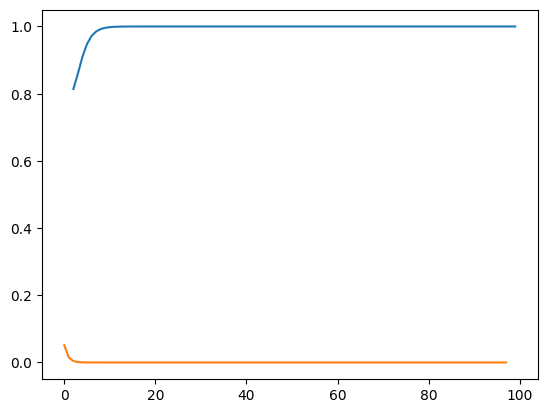

In [4]:
plt.plot(NN,PN1Sim,PN1Real)

One can see that with the real device the probability to solve Simon problem is always very small

The probabiltites we have used above are found as follows

In [5]:
import os
from dotenv import load_dotenv
load_dotenv()

import qiskit as qk
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from numpy import pi
import numpy as np

try:
    from qiskit_textbook.tools import simon_oracle
except ImportError:
    def simon_oracle(b):
        n = len(b)
        qc = QuantumCircuit(2 * n)
        for i in range(n):
            qc.cx(i, n + i)
        for i, bit in enumerate(b):
            if bit == '1':
                qc.cx(0, n + i)
        return qc

# --- IBM Quantum hardware setup (optional) ---
# from qiskit_ibm_runtime import QiskitRuntimeService
# QiskitRuntimeService.save_account(channel='ibm_quantum', token='YOUR_TOKEN', overwrite=True)
# service = QiskitRuntimeService(channel='ibm_quantum', token=os.environ.get('IBM_QUANTUM_TOKEN'))

Define the circuit to apply the Simone oracle to the superposition of all computational basis states and measure results

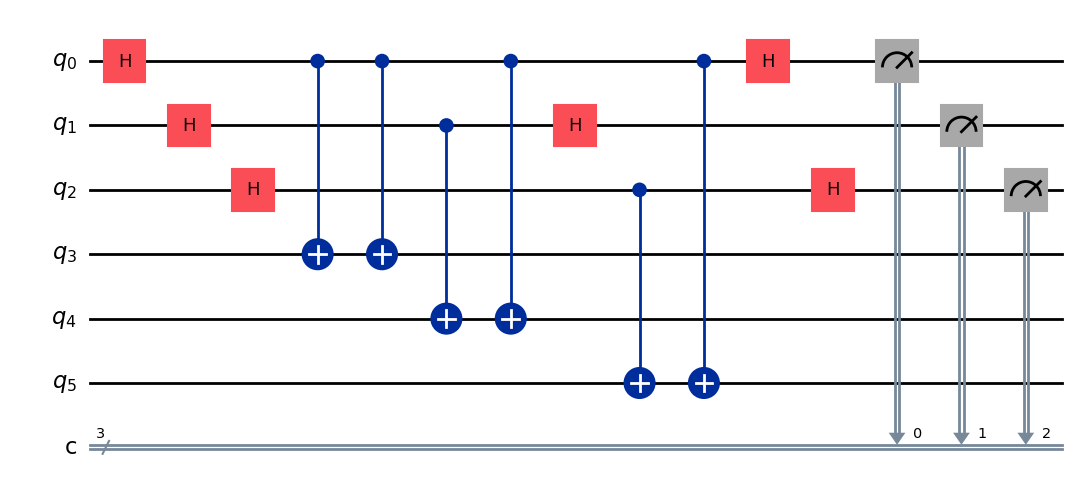

In [6]:
b = '111'
n = len(b)
simon_circuit_2 = QuantumCircuit(n*2, n)

# Apply Hadamard gates before querying the oracle
simon_circuit_2.h(range(n))

# Query oracle
simon_circuit_2 = simon_circuit_2.compose(simon_oracle(b))

# Apply Hadamard gates to the input register
simon_circuit_2.h(range(n))

# Measure qubits
simon_circuit_2.measure(range(n), range(n))
simon_circuit_2.draw(output='mpl',justify='none')

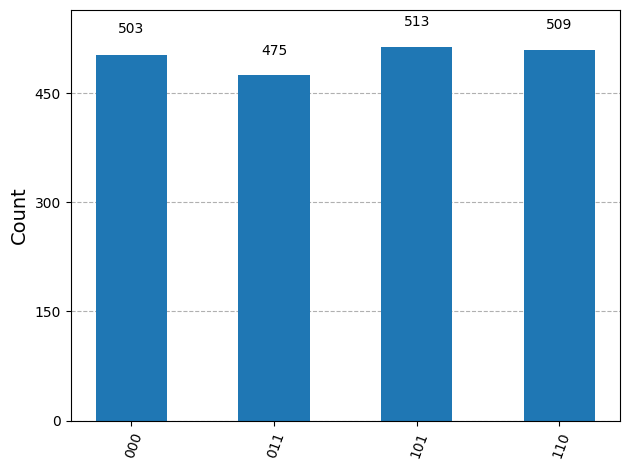

In [7]:
# Execute on the local AerSimulator
backend_sim = AerSimulator()
shots = 2000
job = backend_sim.run(transpile(simon_circuit_2, backend_sim), shots=shots)
device_counts = job.result().get_counts()
plot_histogram(device_counts)

Execute on real device (can take long)

In [8]:
# Run on real IBM device (requires account):
# from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
# service = QiskitRuntimeService(channel='ibm_quantum')
# backend_real = service.least_busy(operational=True, simulator=False, min_num_qubits=6)
# print("Least busy backend:", backend_real.name)
# sampler = Sampler(backend_real)
# job = sampler.run([transpile(simon_circuit_2, backend_real)], shots=2000)
# device_counts = job.result()[0].data.c.get_counts()
# plot_histogram(device_counts)

# Pre-recorded noisy real-device results for analysis below:
print("Real device execution: uncomment block above after setting up credentials.")
print("Pre-recorded noisy real-device results used in analysis:")
device_counts = {'000': 161, '001': 395, '010': 371, '011': 126,
                 '100': 372, '101': 126, '110': 119, '111': 330}
print(device_counts)

Real device execution: uncomment block above after setting up credentials.
Pre-recorded noisy real-device results used in analysis:
{'000': 161, '001': 395, '010': 371, '011': 126, '100': 372, '101': 126, '110': 119, '111': 330}


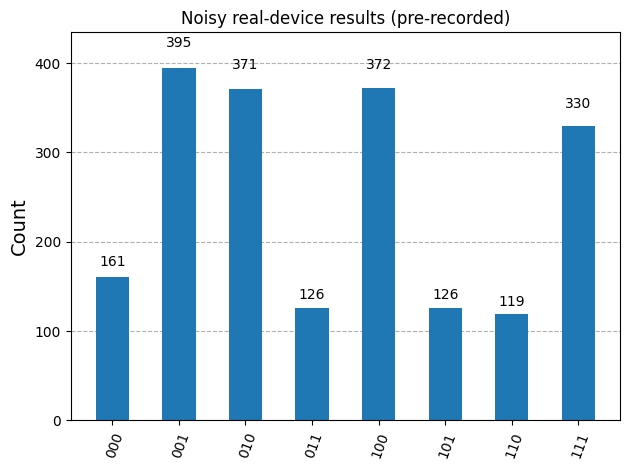

In [9]:
# Re-plot real device results for comparison with simulator
plot_histogram(device_counts, title="Noisy real-device results (pre-recorded)")